# А/В-тестирование алгоритма рекомендаций в развлекательном приложении

**Описание проекта**

Компания разрабатывает развлекательное приложение с бесконечной лентой, похожей на приложения с короткими видео. В продукте используются две модели монетизации:

1. Платная ежемесячная подписка, которая отключает рекламу.
2. Показ рекламы пользователям без подписки.

Команда рекомендательных систем разработала новый алгоритм персональных рекомендаций. Перед полноценным внедрением алгоритма необходимо провести A/B-тест и оценить, действительно ли новая версия повышает пользовательскую вовлечённость.

В рамках проекта были использованы исторические данные по сессиям пользователей, данные за первый день теста и данные за весь период проведения эксперимента.

**Цель проекта** - рассчитать параметры A/B-теста, проверить корректность его проведения и проанализировать результаты эксперимента для развлекательного приложения с бесконечной лентой контента.

Основная бизнес-гипотеза: новый алгоритм рекомендаций должен показывать пользователям более интересный контент и тем самым повышать вовлечённость в приложении.


## Описание данных

Данные представлены в трех таблицах 

- `sessions_project_history` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. 

- `sessions_project_test_part` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 

- `sessions_project_test` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.


## Задача:

Провести A/B‑тест, в котором будет проверятся новый алгоритм рекомендаций для «бесконечной» ленты, поэтому основной фокус сконцентрируем на вовлечённости пользователей.

Новый алгоритм рекомендаций должен увеличить волеченность, за основную метрику можно принять долю успешных сессий, в которых пользователь просмотрел **4 и более страниц**
- Идея продукта: если алгоритм лучше подбирает контент, пользователи дольше остаются в ленте и чаще преодолевают порог из 4 страниц.    
- Ожидаемый эффект: рост доли успешных сессий на несколько процентов относительно базового уровня (минимально значимый эффект для планирования — порядка 3%)


### Работа с историческими данными (EDA)

#### Загрузка  данных

Для начала проработаем исторические данные приложения:

Создадим датафрейм `sessions_history` с историческими данными о сессиях пользователей 

Импортируем библиотеки, необходимые для анализа

In [1]:
import pandas as pd 
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt


In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
display(sessions_history.head(5))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### Знакомство с данными

Для каждого уникального пользователя `user_id` расчитаем количество уникальных сессий.
Выведем на экран все данные из таблицы для одного пользователя с наибольшим количеством сессий.




In [3]:
# Число уникальных сессий на пользователя 
sessions_per_user = (
    sessions_history.groupby('user_id')['session_id'].nunique().reset_index(name='n_sessions'))

display(sessions_per_user.head(10))


,user_id,n_sessions
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2
5,0002A3F1173999FD,5
6,0002D21C2F9CC2A9,2
7,0003352540175CAC,1
8,00044C43F22EF7D7,5
9,0004B29EDCD8C542,1


In [4]:
# максимальное число сессий
max_sessions = sessions_per_user['n_sessions'].max()

# выбираем любого пользователя с этим значением 
top_user_id = (sessions_per_user.loc[sessions_per_user['n_sessions'] == max_sessions, 'user_id'].iloc[0])

print('Пользователь с max количеством сессий:', top_user_id, '(', max_sessions, 'сессий )')


Пользователь с max количеством сессий: 10E0DEFC1ABDBBE0 ( 10 сессий )


In [5]:
top_user_history = sessions_history[sessions_history['user_id'] == top_user_id]

# Вывод сессий одного пользователя
display(top_user_history.head())


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android


#### Анализ числа регистраций

Число зарегистрированных пользователей - одна из важных метрик продукта. Проанализируем,визуализируйте, как менялось число регистраций в приложении за время его существования.


In [6]:
# Приводим дату к формату datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

# Для каждого дня считаем число уникальных пользователей и число зарегистрированных пользователей 
daily = (sessions_history.groupby('session_date').agg(total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', lambda x: x.eq(1).sum())).reset_index())


# Доля зарегистрированных
daily['registered_share'] = daily['registered_users'] / daily['total_users']*100
print(round(daily.head(),2))


  session_date  total_users  registered_users  registered_share
0   2025-08-11         3919               169              4.31
1   2025-08-12         6056               336              5.55
2   2025-08-13         8489               464              5.47
3   2025-08-14        10321               625              6.06
4   2025-08-15        14065               840              5.97


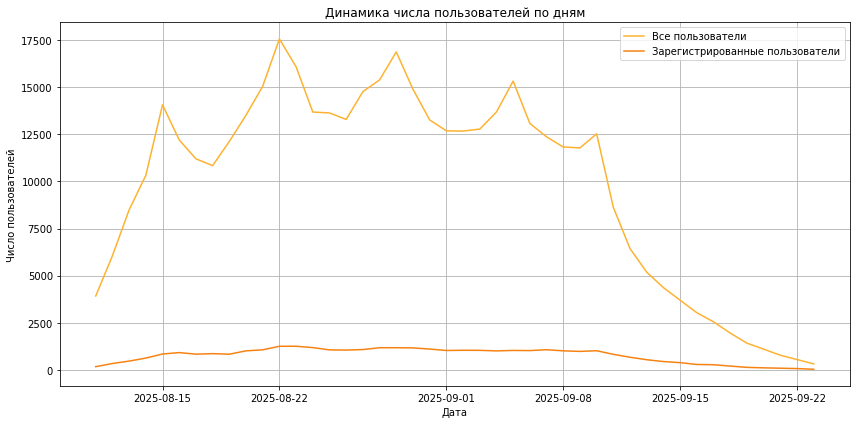

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(daily['session_date'], daily['total_users'],
         label='Все пользователи', color = '#fdb22f' )
plt.plot(daily['session_date'], daily['registered_users'],
         label='Зарегистрированные пользователи', color = '#f68211' )

plt.title('Динамика числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

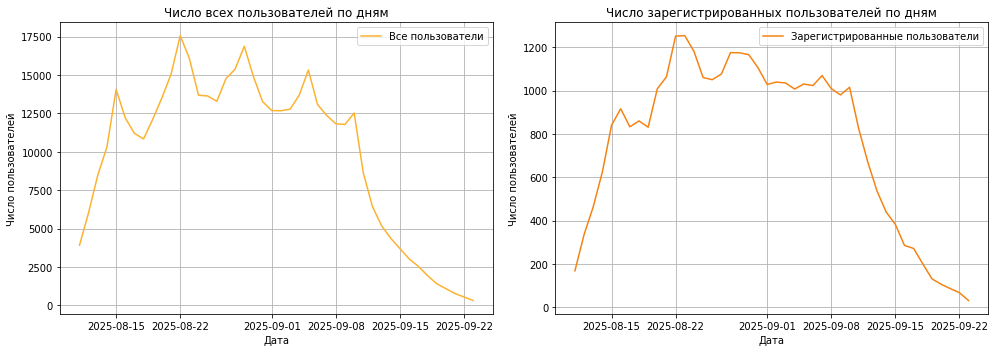

In [35]:
#  Линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Левый график — все пользователи
ax1.plot(daily['session_date'], daily['total_users'], color = '#fdb22f', label='Все пользователи') 
ax1.set_title('Число всех пользователей по дням')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Число пользователей')
ax1.grid(True)
ax1.legend()

# Правый график — зарегистрированные
ax2.plot(daily['session_date'], daily['registered_users'], color='#f68211',
         label='Зарегистрированные пользователи') 
ax2.set_title('Число зарегистрированных пользователей по дням')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Число пользователей')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()



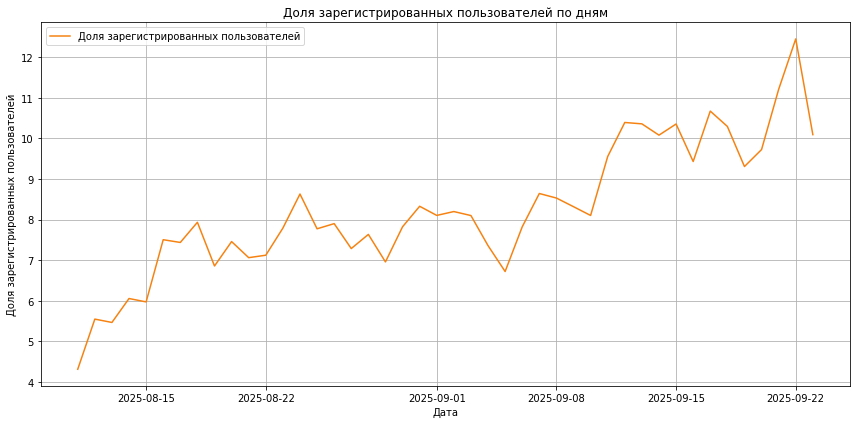

In [9]:
# Доля зарег пользователей 

plt.figure(figsize=(12, 6))

plt.plot(daily['session_date'], daily['registered_share'],
         label='Доля зарегистрированных пользователей', color= '#f68211')

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


#### Анализ числа просмотренных страниц

Число просмотренных страниц в приложении еще одна важная метрика. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

In [10]:
# Подсчет числа сессий по кол-ву страниц

pages_sessions = (sessions_history.groupby('page_counter')['session_id'].count().reset_index(name='n_sessions').sort_values('page_counter'))

print(pages_sessions.head())


   page_counter  n_sessions
0             1       29160
1             2      105536
2             3      166690
3             4      105569
4             5       26288


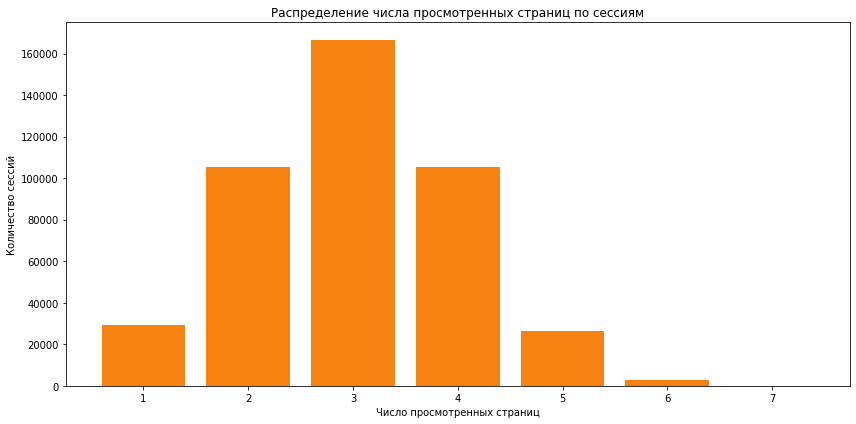

In [11]:
# Столбчатая диаграмма 

plt.figure(figsize=(12, 6))

plt.bar(pages_sessions['page_counter'],
        pages_sessions['n_sessions'], color = '#f68211')

plt.title('Распределение числа просмотренных страниц по сессиям') 
plt.xlabel('Число просмотренных страниц') 
plt.ylabel('Количество сессий')

plt.tight_layout()
plt.show()


#### Доля пользователей, просмотревших более четырёх страниц

Прокси-метрикой стоит считать сессии, в рамках которых пользователь просмотрел 4 и более страниц. Это говорит об удовлетворённости контентом и алгоритмами рекомендаций. 

In [12]:
# Успешные сессии
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

display(sessions_history.head())


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [13]:
# Доля успешных сессий 
daily_good_share = (sessions_history.groupby('session_date')['good_session'].mean().reset_index(name='good_session_share'))

print(daily_good_share.head())


  session_date  good_session_share
0   2025-08-11            0.312835
1   2025-08-12            0.302015
2   2025-08-13            0.306750
3   2025-08-14            0.316055
4   2025-08-15            0.304941


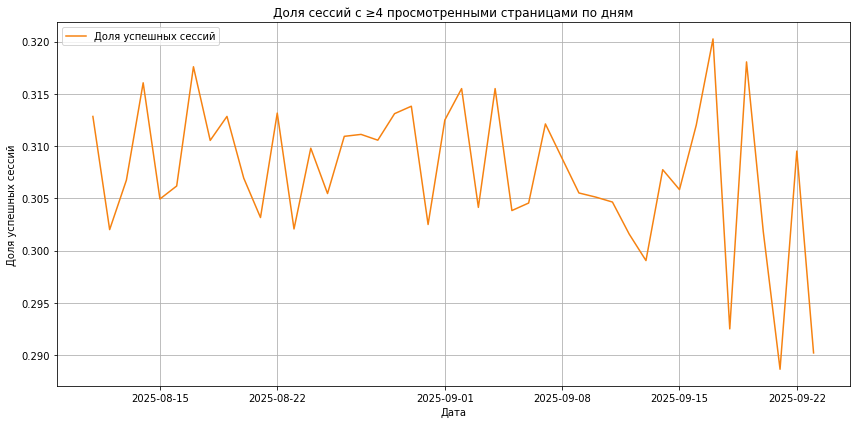

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(daily_good_share['session_date'],
         daily_good_share['good_session_share'],
         label='Доля успешных сессий', color = '#f68211')

plt.title('Доля сессий с ≥4 просмотренными страницами по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**Промежуточные выводы**

По историческим данным удалось собрать базовую картину продукта и поведения пользователей.

**Пользовательская база**

Число активных пользователей в день сначала растёт, затем постепенно падает к концу периода, что говорит о фазе активного роста с последующим спадом или указывает на сезонность. Количество зарегистрированных пользователей также растёт, а доля зарегистрированных от всех пользователей по дням увеличивается.

**Вовлечённость и просмотры страниц**

Распределение page_counter показывает, что основная масса сессий — с 2–4 просмотренными страницами, единичные страницы встречаются заметно реже.  
Доля «успешных» сессий (≥4 страницы) держится примерно в районе 30% с умеренными колебаниями по дням, без резких провалов или всплесков. Это значит, что базовый уровень вовлечённости стабильный.

**Структура аудитории**

Распределение по устройствам относительно устойчиво, доминирует Android, далее идут PC и iPhone, доля Mac заметно ниже. Это важно для последующей проверки равномерности в тесте. По регионам основная аудитория приходится на два крупных сегмента (CIS и MENA), доля EU меньше, но тоже стабильна. 

Данные выглядят чистыми и стабильными,на них можно опираться при расчёте параметров A/B‑теста и интерпретации его результатов.


### Подготовка к тесту

Для проведения теста выполним несколько шагов:

- Сформулируем нулевую и альтернативную гипотезы

- Определим целевую метрику

- Рассчитаем необходимый размер выборки

- Рассчитаем необходимую длительность проведения теста

#### Формулировка нулевой и альтернативной гипотез


За целевую метрику примем метрику вовлеченности пользователя в ленту, а именно долю "успешных" сессий, где пользователь просмотрел не менее 4 страниц. Именно эта метрика даст понимание, насколько интересен показанный контент. 

Сформулируйте нулевую и альтернативную гипотезы:

Нулевая гепотиза Н0: доля "успешных" сессий в группе с новым алгоритмом не отличается от доли в контрольной группе.

Альтернативная гепотиза Н1: доля успешных сессий в группе с новым алгоритмом выше, чем в контрольной группе.






#### Расчёт размера выборки

Расчитаем размер выборки, для этого установим следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

In [37]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1- beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект

p1 = p
p2 = p1 + mde
effect_size = proportion_effectsize(p1, p2)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)


print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 82081


#### Расчёт длительности A/B-теста


In [38]:
daily_users = (sessions_history.groupby('session_date')['user_id'].nunique().reset_index(name='n_users'))


# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = daily_users['n_users'].mean()


# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
total_sample_size = sample_size*2
test_duration = ceil(total_sample_size / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users.round(2)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.36 пользователей в день составит 9 дней


### Мониторинг А/В-теста

#### Проверка распределения пользователей

A/B-тест запущен, следующим шагом убедимся, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.
Для этого используем данные за первые три дня.

- Сохраним датафрейм `sessions_test_part`  с историческими данными о сессиях пользователей 
- Расчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.
- Расчитаем процентную разницу в количестве пользователей в группах A и B. 

Для расчёта процентной разницы используем формулу:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [17]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
display(sessions_test_part.head(5))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [18]:
# Уникальные пользователи по группам 
users_by_group = (sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index(name='n_users'))
users_by_group = users_by_group.set_index('test_group')['n_users']

print(users_by_group)

test_group
A    1477
B    1466
Name: n_users, dtype: int64


In [19]:
#  Расчёт процентной разницы
A = users_by_group['A']
B = users_by_group['B']

P = 100* abs(A-B)/A

print(f'Процентная разница в количестве пользователей в группах A и B: {P:.2f}%')

Процентная разница в количестве пользователей в группах A и B: 0.74%


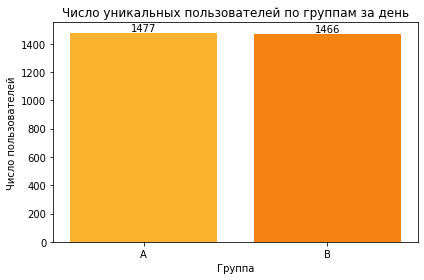

In [20]:
# 
plt.figure(figsize=(6, 4))

plt.bar(users_by_group.index,
        users_by_group.values,
        color=['#fdb22f', '#f68211'])

plt.title('Число уникальных пользователей по группам за день')
plt.xlabel('Группа')
plt.ylabel('Число пользователей')

for x, y in zip(users_by_group.index, users_by_group.values):
    plt.text(x, y + users_by_group.values.max() * 0.01,
             str(y), ha='center')

plt.tight_layout()
plt.show()


#### Проверка пересечений пользователей

Помимо проверки равенства количества пользователей в группах, необходимо убедиться в том, что группы независимы. Для этого нужно проверим, что никто из пользователей случайно не попал в обе группы одновременно.


In [21]:
users_A = set(
    sessions_test_part.loc[sessions_test_part['test_group'] == 'A', 'user_id']
)
users_B = set(
    sessions_test_part.loc[sessions_test_part['test_group'] == 'B', 'user_id']
)

intersection = users_A & users_B
n_intersection = len(intersection)

print(f'Число пользователей, попавших одновременно в группы A и B: {n_intersection}')



Число пользователей, попавших одновременно в группы A и B: 0


#### Равномерность разделения пользователей по устройствам

Также убедимся, что пользователи равномерно распределены по доступным категориальным переменным.



In [22]:
# Доля типов устройств в группе A
device_A = (
    sessions_test_part[sessions_test_part['test_group'] == 'A']['device']
      .value_counts(normalize=True)
      .sort_index()
)

# Доля типов устройств в группе B
device_B = (
    sessions_test_part[sessions_test_part['test_group'] == 'B']['device']
      .value_counts(normalize=True)
      .sort_index()
)

# Объединим индексы, чтобы порядок категорий совпадал 
all_devices = sorted(set(device_A.index) | set(device_B.index)) 
device_A = device_A.reindex(all_devices, fill_value=0) 
device_B = device_B.reindex(all_devices, fill_value=0)

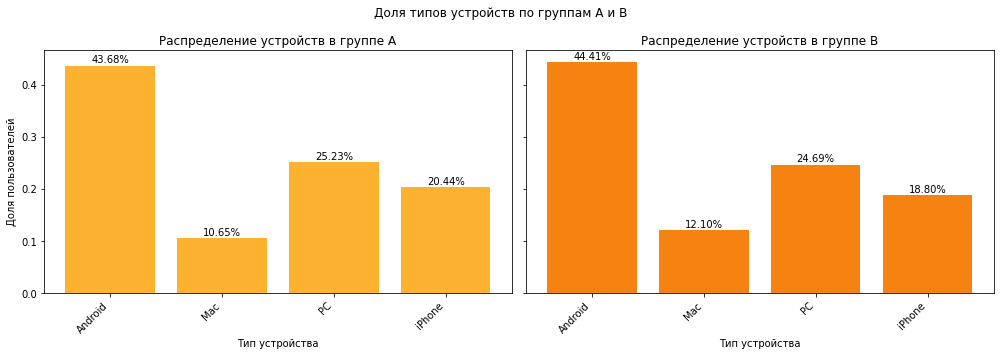

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Группа A
x_A = range(len(all_devices))
axes[0].bar(x_A, device_A.values, color='#fdb22f') 
axes[0].set_title('Распределение устройств в группе A') 
axes[0].set_xlabel('Тип устройства') 
axes[0].set_ylabel('Доля пользователей')
axes[0].set_xticks(x_A)
axes[0].set_xticklabels(all_devices, rotation=45, ha='right')
for x, y in zip(x_A, device_A.values):
    axes[0].text(x, y + 0.005, f'{y:.2%}', ha='center', rotation=0)

# Группа B
x_B = range(len(all_devices))
axes[1].bar(x_B, device_B.values, color='#f68211') 
axes[1].set_title('Распределение устройств в группе B') 
axes[1].set_xlabel('Тип устройства')
axes[1].set_xticks(x_B)
axes[1].set_xticklabels(all_devices, rotation=45, ha='right')
for x, y in zip(x_B, device_B.values):
    axes[1].text(x, y + 0.005, f'{y:.2%}', ha='center', rotation=0)

fig.suptitle('Доля типов устройств по группам A и B')
plt.tight_layout()
plt.show()




#### Равномерность распределения пользователей по регионам

Теперь убедимся, что пользователи равномерно распределены по регионам.

In [24]:
# Доли регионов в A
region_A = (
    sessions_test_part[sessions_test_part['test_group'] == 'A']['region']
      .value_counts(normalize=True)
      .sort_index()
)

# Доли регионов в B
region_B = (
    sessions_test_part[sessions_test_part['test_group'] == 'B']['region']
      .value_counts(normalize=True)
      .sort_index()
)

# общий список регионов
all_regions = sorted(set(region_A.index) | set(region_B.index)) 
region_A = region_A.reindex(all_regions, fill_value=0) 
region_B = region_B.reindex(all_regions, fill_value=0)


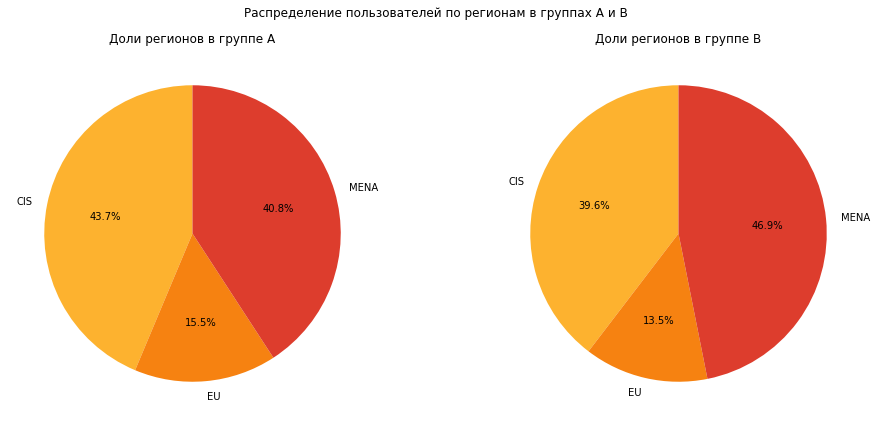

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Группа A
axes[0].pie(
    region_A.values,
    labels=all_regions,
    autopct='%1.1f%%',
    startangle=90, colors = ['#fdb22f','#f68211','#dd3d2d'])
axes[0].set_title('Доли регионов в группе A')

# Группа B
axes[1].pie(
    region_B.values,
    labels=all_regions,
    autopct='%1.1f%%',
    startangle=90, colors = ['#fdb22f','#f68211','#dd3d2d'])
axes[1].set_title('Доли регионов в группе B')

fig.suptitle('Распределение пользователей по регионам в группах A и B')
plt.tight_layout()
plt.show()


#### Вывод после проверки A/B-теста


На основе проведённого анализа A/B-теста можно сделать следующие выводы:

- Количество пользователей в группах:

Число уникальных пользователей за день теста почти одинаковое, в группе A -  1477 пользователей, в группе B - 1466 пользователей, разница составляет 0,74 %. Такое расхождение считается несущественным и не должно влиять на результаты теста.

- Независимость выборок:

При проверке пересечения множеств user_id между группами A и B, пользователей, попавших одновременно в обе группы, не обнаружено. Это означает, что группы независимы.

- Равномерность по устройствам и регионам:

Распределение по типам устройств device в группах A и B очень похоже. Доли в каждой категории отличаются незначительно, визуально столбчатые диаграммы почти совпадают. Распределение по регионам region в группах A и B также близкое. По круговым диаграммам видно, что распределение без явного перекоса одной группы относительно другой.


**Итоговое заключение**

- Существенных различий в размере групп нет.
- Пересечений пользователей между группами не обнаружено, выборки независимы.
- Распределение по ключевым категориальным признакам (устройства, регионы) равномерно и сопоставимо между A и B.

Следовательно, в первый день A/B теста рандомизация и разбиение трафика работают корректно, явных нарушений дизайна эксперимента не наблюдается, можно переходить к анализу продуктовых метрик.


### Проверка результатов A/B-теста


A/B-тест завершён, убедимся в корректности теста и выводах на основании результатов за все дни проведения эксперимента.

#### Получение результатов теста и подсчёт основной метрики

- Сокраним датафрейм `sessions_test`  с историческими данными о сессиях пользователей 

- Создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [26]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

display(sessions_test.head(5))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [27]:
# Столбец good_session с успешными сессиями

sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

display(sessions_test.head())
print(sessions_test.info())


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100005 non-null  object
 1   session_id         100005 non-null  object
 2   session_date       100005 non-null  object
 3   session_start_ts   100005 non-null  object
 4   install_date       100005 non-null  object
 5   session_number     100005 non-null  int64 
 6   registration_flag  100005 non-null  int64 
 7   page_counter       100005 non-null  int64 
 8   region             100005 non-null  object
 9   device             100005 non-null  object
 10  test_group         100005 non-null  object
 11  good_session       100005 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 9.2+ MB
None


#### Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, убедимся что тест проведён корректно.


In [28]:
sessions_test['session_date'] = pd.to_datetime(sessions_test['session_date'])

# Число уникальных сессий по дням и группам 
daily_sessions = (sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().reset_index(name='n_sessions'))

print(daily_sessions.head())

  session_date test_group  n_sessions
0   2025-10-14          A        1502
1   2025-10-14          B        1628
2   2025-10-15          A        2235
3   2025-10-15          B        2283
4   2025-10-16          A        3280


In [29]:
# Формируем две выборки "сессии в день" по группам 
a_daily = daily_sessions.loc[daily_sessions['test_group'] == 'A', 'n_sessions'] 
b_daily = daily_sessions.loc[daily_sessions['test_group'] == 'B', 'n_sessions']

# t-тест на равенство средних 
t_stat, p_value = stats.ttest_ind(a_daily, b_daily, equal_var=False)

print('Среднее число сессий в день, группа A:', a_daily.mean()) 
print('Среднее число сессий в день, группа B:', b_daily.mean()) 

print('p-value:', p_value)


Среднее число сессий в день, группа A: 2477.55
Среднее число сессий в день, группа B: 2522.7
p-value: 0.9382195854082714


Интерпретация:

p-value > 0.05 - значит, статистических оснований считать среднее количество дневных сессий различным нет. По трафику группы А и В сопостовимы, тест корректен по этому критерию.

#### Сравнение доли успешных сессий

Проанализируем ключевую метрику — долю успешных сессий.


In [30]:
# Доля успешных сессий по группам
success_rate = (sessions_test.groupby('test_group')['good_session'].mean())

rate_A = success_rate['A']
rate_B = success_rate['B']
diff = rate_B - rate_A

print(f'Доля успешных сессий в группе A: {rate_A:.4f} ({rate_A:.2%})') 
print(f'Доля успешных сессий в группе B: {rate_B:.4f} ({rate_B:.2%})') 

print(f'Разница (B - A): {diff:.4f} ({diff:.1%})')


Доля успешных сессий в группе A: 0.3077 (30.77%)
Доля успешных сессий в группе B: 0.3183 (31.83%)
Разница (B - A): 0.0106 (1.1%)


#### Оценка статистической значимости изменения ключевой метрики


In [31]:
# Считаем число успешных сессий и общее число сессий по группам 
agg = (sessions_test.groupby('test_group')['good_session'].agg(['sum', 'count']))

success_A, total_A = agg.loc['A', ['sum', 'count']] 
success_B, total_B = agg.loc['B', ['sum', 'count']]


In [32]:
# z-тест для двух долей
count = [success_A, success_B]      # число успешных сессий
nobs = [total_A, total_B]           # общее число сессий

stat, p_value = proportions_ztest(count, nobs)

print(f'Доля успешных сессий A: {success_A/total_A:.4f} ({success_A/total_A:.2%})') 
print(f'Доля успешных сессий B: {success_B/total_B:.4f} ({success_B/total_B:.2%})') 
print(f'Абсолютная разница (B - A): {(success_B/total_B - success_A/total_A):.4f} 'f'({(success_B/total_B - success_A/total_A):.1%})')
print(f"p-value: {p_value:.4f}")



Доля успешных сессий A: 0.3077 (30.77%)
Доля успешных сессий B: 0.3183 (31.83%)
Абсолютная разница (B - A): 0.0106 (1.1%)
p-value: 0.0003


Интерпретация:

p-value < 0.05 - означает, что получить такую или более сильную разницу в долях успешных сессий между группами случайно.
При таком уровне значимости нулевая гипотеза о равенстве долей успешных сессий отвергается и рост доли успешных сессий в тестовой группе на 1,1% статистически значим. 

#### Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Характеристики эксперимента**

- A/B‑тест, где:
  - группа A — старый алгоритм рекомендаций,  
  - группа B — новый алгоритм.   
- Ключевая метрика: доля «успешных» сессий, в которых пользователь просмотрел не менее 4 страниц (`good_session = 1`).  
- Среднее количество сессий в день:  
  - группа A — 2477.55,  
  - группа B — 2522.7;  
- t‑тест дал p-value ≈ 0.938, что говорит об отсутствии статистически значимых отличий по трафику между группами. Это означает, что нагрузка и объём наблюдений сопоставимы, дизайн эксперимента корректен по этому параметру.  
- Эксперимент длился несколько дней и охватывал достаточно трафика для оценки эффекта.

**Влияние нового алгоритма на ключевую метрику**

- Доля успешных сессий:  
  - группа A: 0.3077 (30.77%),  
  - группа B: 0.3183 (31.83%).  
- Абсолютный прирост: 1.1%, то есть в группе с новым алгоритмом на каждые 100 сессий примерно на одну–две сессии больше становятся успешными по заданному критерию. Это прямо говорит о росте вовлечённости в ленту.

**Статистическая значимость эффекта**

- Для сравнения долей успешных сессий использовался тест для двух пропорций (z‑тест).  
- Результат: p-value = 0.0003 при уровне значимости 0.05. Такое значение показывает, что вероятность получить наблюдаемый или более сильный рост доли успешных сессий случайно, если на самом деле алгоритм не влияет на поведение, менее 0.1%. Нулевая гипотеза о равенстве долей уверенно отвергается, эффект статистически значим.




Эксперимент показал, что новый алгоритм даёт небольшой, но устойчивый и статистически значимый рост ключевой метрики при корректной рандомизации.

Рекомендация по продукту

- Трафик между группами распределён равномерно, среднее число сессий в день не отличается статистически значимо.  
- Новый алгоритм рекомендаций даёт статистически значимый рост доли успешных сессий примерно на 1,1% а значит, пользователи чаще потребляют больше контента за одну сессию.  
- Рост вовлечённости может веступать драйвером конверсии в регистрацию/подписку и рекламной монетизации, поэтому даже небольшой, но устойчивый прирост имеет бизнес‑смысл.

**Итоговый вывод:**

Эксперимент корректен, эффект по ключевой метрике значим. Нововведение рекомендуется внедрять на всех пользователей, с параллельным мониторингом влияния на конверсию в регистрацию/подписку и доходов от рекламы.
